### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

In [4]:
import tensorflow as tf
from tensorflow import data
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import layers, Model, utils, callbacks, optimizers

In [5]:
import albumentations as A

### Step 2: Constant

In [6]:
AUTO = data.experimental.AUTOTUNE
DATA_FOLD = './data/chest_xray/'
IMG_HEIGH = 224
IMG_WIDTH = 224
IMG_CHANNEL = 3
EPOCHS = 20
BATCH_SIZE = 64

### Step 3: Load Data

In [7]:
train = pd.DataFrame()
for label in os.listdir(f'{DATA_FOLD}train/'):
    temp = pd.DataFrame(
        {
            'img_id': [f'train/{label}/{img_id}' for img_id in os.listdir(f'{DATA_FOLD}train/{label}')],
            'label': label
        }
    )
    train = pd.concat([train, temp], ignore_index=True)

In [8]:
value = pd.DataFrame()
for label in os.listdir(f'{DATA_FOLD}val/'):
    temp = pd.DataFrame(
        {
            'img_id': [f'val/{label}/{img_id}' for img_id in os.listdir(f'{DATA_FOLD}val/{label}')],
            'label': label
        }
    )
    value = pd.concat([value, temp], ignore_index=True)

In [9]:
test = pd.DataFrame()
for label in os.listdir(f'{DATA_FOLD}test/'):
    temp = pd.DataFrame(
        {
            'img_id': [f'test/{label}/{img_id}' for img_id in os.listdir(f'{DATA_FOLD}test/{label}')],
            'label': label
        }
    )
    test = pd.concat([test, temp], ignore_index=True)

In [10]:
train.sample(5)

,img_id,label
2423,train/PNEUMONIA/person1496_virus_2605.jpeg,PNEUMONIA
4634,train/PNEUMONIA/person671_virus_1260.jpeg,PNEUMONIA
746,train/NORMAL/NORMAL2-IM-0577-0001.jpeg,NORMAL
3270,train/PNEUMONIA/person308_virus_630.jpeg,PNEUMONIA
428,train/NORMAL/IM-0604-0001.jpeg,NORMAL


### Step 4: Exploaring Data

In [11]:
temp = A.Resize(IMG_HEIGH, IMG_WIDTH)

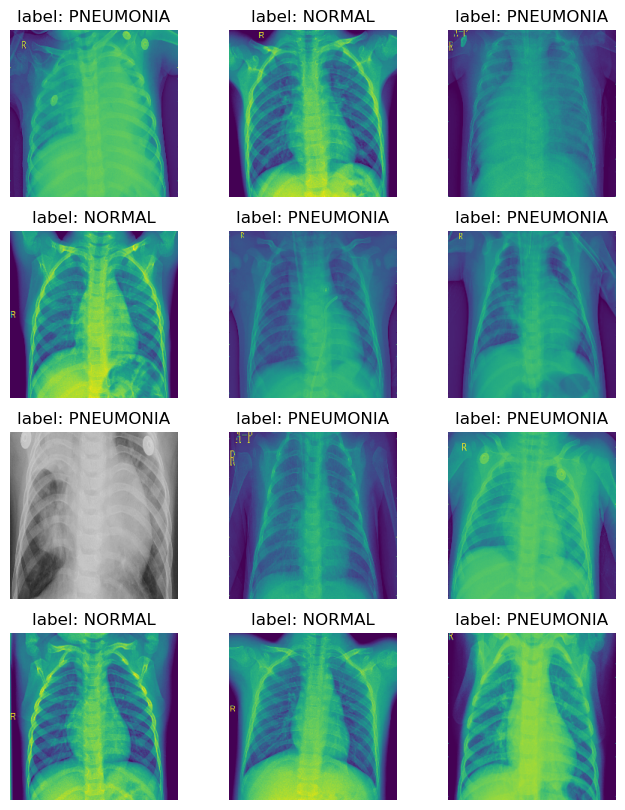

In [12]:
plt.figure(figsize=(8, 10))
for i in range(12):
    plt.subplot(4, 3, i+1)
    k = np.random.randint(train.shape[0])
    label = train.loc[k, 'label']
    img_id = train.loc[k, 'img_id']
    img = plt.imread(f'{DATA_FOLD}/{img_id}')
    img = temp(image=img)['image']
    plt.imshow(img)
    plt.title(f'label: {label}')
    plt.axis('off')

### Step 5: Preparing Data

#### Label Encode

In [13]:
le = LabelEncoder()

In [14]:
train['label_id'] = le.fit_transform(train['label'])
value['label_id'] = le.transform(value['label'])
test['label_id'] = le.transform(test['label'])

#### Albumentation

In [15]:
preparing = A.Resize(IMG_HEIGH, IMG_WIDTH)

In [16]:
transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomGamma(p=0.2),
        A.RandomBrightnessContrast(p=0.2),
        A.CoarseDropout(p=0.2)
    ]
)

#### Build Generator

In [17]:
def Generator(df, img_shape, is_train):
    def gen():
        for _, row in df.iterrows():
            img_id = row['img_id']
            label_id = row['label_id']
            img = cv2.imread(f'{DATA_FOLD}{img_id}')
            img = preparing(image=img)['image']
            if is_train:
                img = transform(image=img)['image']
            img = img.astype('float32') / 255.0
            yield img, label_id
    return data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=img_shape, dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.uint8)
        )
    )

In [18]:
def get_generator(df, img_shape, batch_size, is_train=True):
    gen = Generator(df, img_shape, is_train)
    gen = gen.map(
        lambda x, y: (x, tf.one_hot(y, len(le.classes_)))
    )
    if is_train:
        gen = gen.shuffle(min(len(df), 1000))
    gen = gen.batch(batch_size)
    gen = gen.prefetch(AUTO)
    return gen

In [19]:
train_generator = get_generator(train, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE)
value_generator = get_generator(value, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE, is_train=False)
test_generator = get_generator(test, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE, is_train=False)

In [20]:
for img, label in train_generator.take(1):
    print(img.shape, label.shape)

(64, 224, 224, 3) (64, 2)


### Step 6: Model Development

#### Build Model

In [21]:
pre_trained_model = VGG16(
    input_shape=(IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL),
    weights='imagenet',
    include_top=False
)

In [22]:
pre_trained_model.trainable = True

In [23]:
x = layers.Flatten()(pre_trained_model.output)
outputs = layers.Dense(len(le.classes_), activation='softmax')(x)

In [24]:
model = Model(pre_trained_model.input, outputs)

In [25]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 2)                   │          50,178 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 14,764,866 (56.32 MB)

 Trainable params: 14,764,866 (56.32 MB)

 Non-trainable params: 0 (0.00 B)

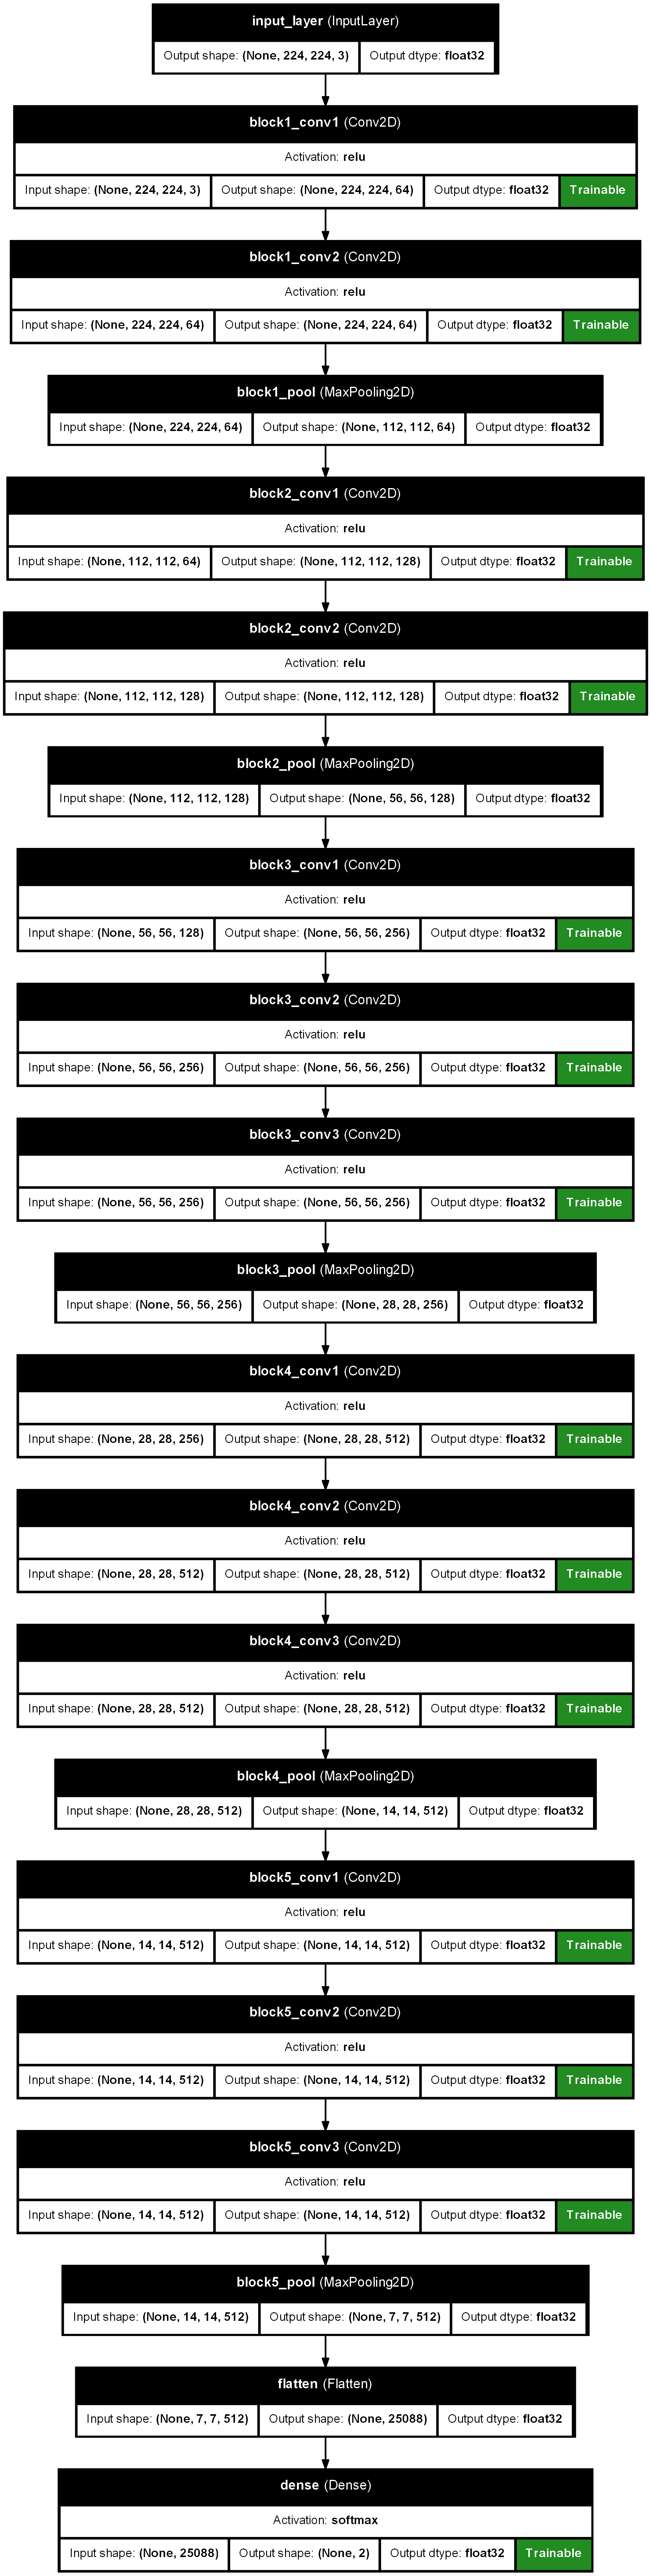

In [26]:
utils.plot_model(
    model,
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    expand_nested=True,
    show_layer_activations=True,
    show_trainable=True,
)

#### Compile Model

In [27]:
optimizer = optimizers.Adam(learning_rate=0.001, clipnorm=1.0)

In [28]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

#### Train Model

In [29]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=0,
    restore_best_weights=True
)

In [30]:
lr_schedule = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    verbose=0
)

In [31]:
history = model.fit(
    train_generator,
    validation_data=value_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping, lr_schedule]
)

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1266s 15s/step - accuracy: 0.8462 - loss: 197.5143 - val_accuracy: 0.5000 - val_loss: 1.7520 - learning_rate: 0.0010
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1302s 16s/step - accuracy: 0.8104 - loss: 0.7608 - val_accuracy: 0.5000 - val_loss: 1.8370 - learning_rate: 0.0010
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1292s 16s/step - accuracy: 0.8622 - loss: 0.9148 - val_accuracy: 0.5000 - val_loss: 4.3130 - learning_rate: 0.0010
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1310s 16s/step - accuracy: 0.8599 - loss: 0.3798 - val_accuracy: 0.5000 - val_loss: 1.7428 - learning_rate: 0.0010
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1292s 16s/step - accuracy: 0.8993 - loss: 0.2806 - val_accuracy: 0.5000 - val_loss: 2.4226 - learning_rate: 0.0010
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1312s 16s/step - accuracy: 0.9057 - loss: 0.2778 - val_accuracy: 0.7500 - val_loss: 0.8697 - learning_rate: 0.0010
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1310s 16s/step - accuracy: 0.9400 - loss: 

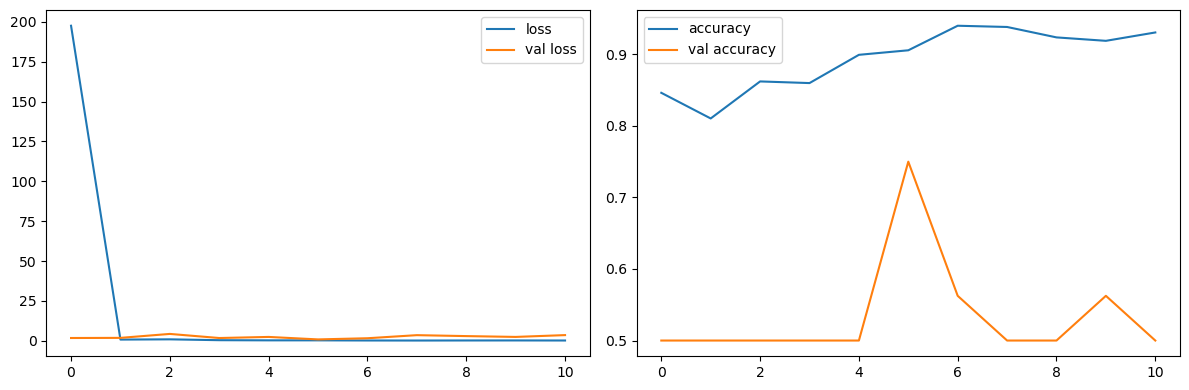

In [34]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.tight_layout()

#### Evaluate Model

In [35]:
loss, accuracy = model.evaluate(test_generator, verbose=0)
print(f'test loss: {round(loss, 3)}, test accuracy: {round(accuracy, 3)}')

test loss: 0.861, test accuracy: 0.768


In [36]:
test_pred = model.predict(test_generator)

10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step


In [38]:
confuse_matrix = metrics.confusion_matrix(test['label_id'], np.argmax(test_pred, axis=1))

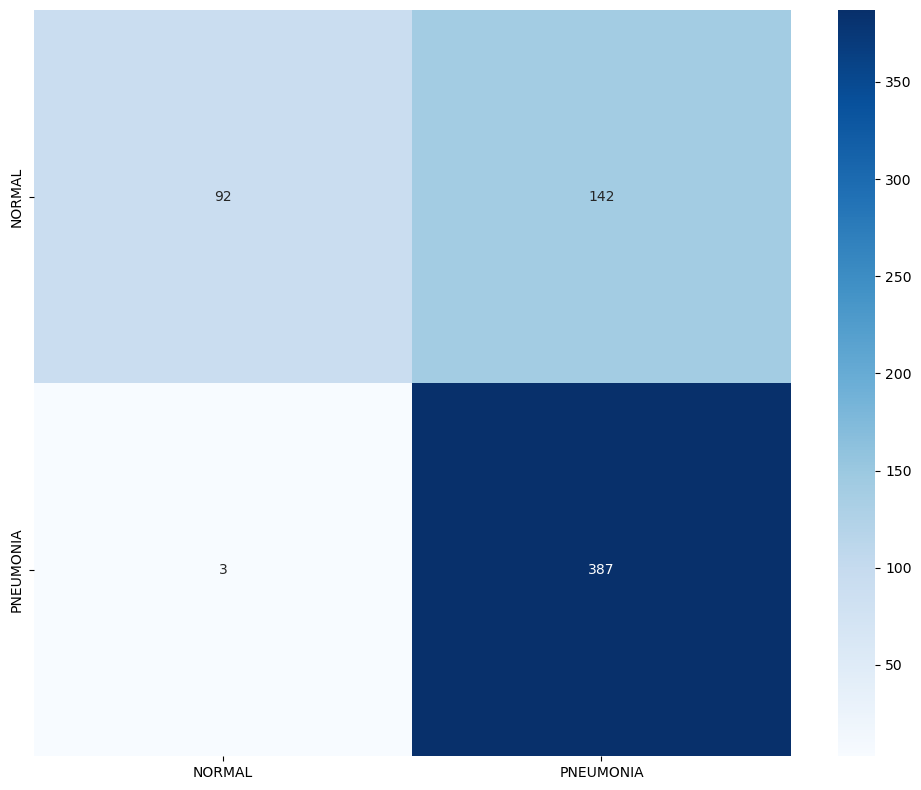

In [39]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    confuse_matrix,
    fmt='d',
    annot=True,
    cmap=plt.cm.Blues,
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.tight_layout()